In [47]:
import pandas as pd
import pyarrow as pa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import calendar

In [50]:
month_order = list(calendar.month_name)[1:]
day_order = list(calendar.day_name)[1:]

In [32]:
df = pd.read_parquet("../data/processed/cinema_dataset_processed.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142399 entries, 0 to 142398
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   film_code     142399 non-null  int64         
 1   cinema_code   142399 non-null  int64         
 2   date          142399 non-null  datetime64[us]
 3   month         142399 non-null  int64         
 4   day           142399 non-null  int64         
 5   show_time     142399 non-null  int64         
 6   capacity      142399 non-null  float64       
 7   tickets_out   142399 non-null  int64         
 8   tickets_sold  142399 non-null  int64         
 9   ticket_use    142399 non-null  int64         
 10  ticket_price  142399 non-null  float64       
 11  total_sales   142399 non-null  float64       
 12  occu_perc     142399 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(8)
memory usage: 14.1 MB


In [33]:
df.head()

,film_code,cinema_code,date,month,day,show_time,capacity,tickets_out,tickets_sold,ticket_use,ticket_price,total_sales,occu_perc
0,1471,448,2018-02-21,2,21,2,559.045226,0,267,267,119.962547,32030.0,47.76
1,1471,518,2018-02-23,2,23,1,144.927536,0,3,3,60.000000,180.0,2.07
2,1485,304,2018-03-14,3,14,8,1694.677871,0,363,363,119.008264,43200.0,21.42
3,1483,83,2018-03-14,3,14,10,1428.571429,0,3,3,100.000000,300.0,0.21
4,1483,262,2018-03-14,3,14,3,958.904110,0,7,7,80.000000,560.0,0.73


In [34]:
df["weekday"] = df["date"].dt.day_name()
df["month_name"] = df["date"].dt.month_name()

In [36]:
date_min = df["date"].min()
date_max = df["date"].max()
print(f"{date_min} - {date_max}")
# Tenemos 10 meses de ventas

2018-02-21 00:00:00 - 2018-11-04 00:00:00


In [37]:
df.groupby("month_name")["total_sales"].sum()

month_name
April        3.485109e+08
August       2.582754e+08
February     3.221000e+04
July         2.648552e+08
June         1.040015e+08
March        1.921256e+08
May          2.395851e+08
November     2.269203e+07
October      2.316603e+08
September    9.656638e+07
Name: total_sales, dtype: float64

In [38]:
# Se nota algo raro en febrero
df.groupby('month_name')['total_sales'].count()

month_name
April        18288
August       19718
February         2
July         19647
June         17199
March         7967
May          22742
November      2139
October      20033
September    14664
Name: total_sales, dtype: int64

In [39]:
# Se eliminara febrero del análisis porque solo contiene 2 registros, lo que genera un sesgo por falta de datos
df = df[df['month'] != 2]

In [40]:
# Total ventas
total_sales = df["total_sales"].sum()
print(f"Ventas totales ${total_sales:,.0f} en el periodo {date_min} - {date_max}")

Ventas totales $1,758,272,420 en el periodo 2018-02-21 00:00:00 - 2018-11-04 00:00:00


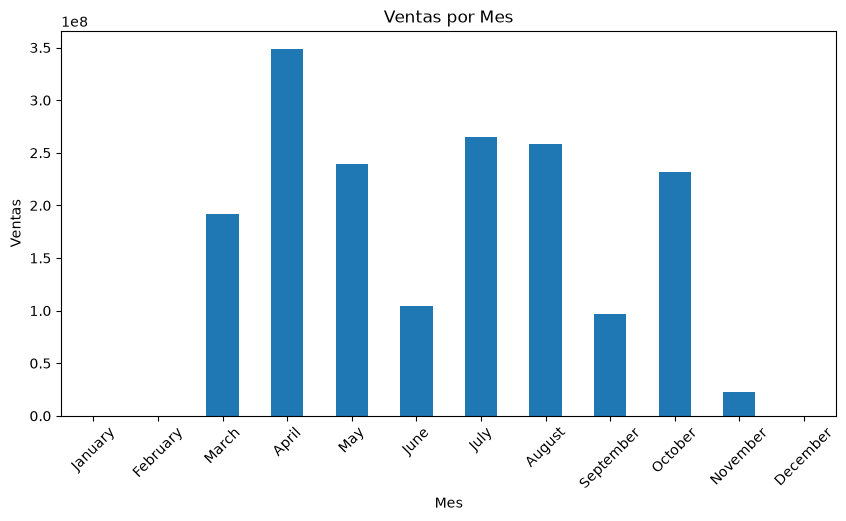

In [49]:
# Ventas por mes
ventas_mes = df.groupby("month_name")["total_sales"].sum()
ventas_mes = ventas_mes.reindex(month_order)
ventas_mes.plot(kind="bar", figsize=(10,5), title="Ventas por Mes")
plt.ylabel("Ventas")
plt.xlabel("Mes")
plt.xticks(rotation=45)
plt.show()

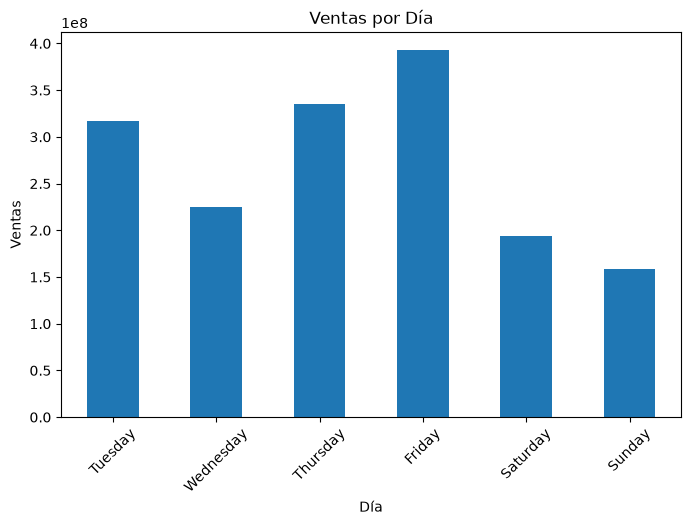

In [55]:
# Ventas por día
ventas_dia = df.groupby("weekday")["total_sales"].sum()
ventas_dia = ventas_dia.reindex(day_order)
ventas_dia.plot(kind="bar", figsize=(8,5), title="Ventas por Día")
plt.ylabel("Ventas")
plt.xlabel("Día")
plt.xticks(rotation=45)
plt.show()

In [43]:
# Que cines generan más ingresos?
df.groupby("cinema_code")["total_sales"].sum().sort_values(ascending=False).head(10)

cinema_code
448    2.141987e+08
304    1.017010e+08
163    6.285289e+07
524    5.930630e+07
489    5.883105e+07
344    5.732276e+07
352    4.236976e+07
450    4.194746e+07
518    3.987923e+07
71     3.906324e+07
Name: total_sales, dtype: float64

In [44]:
# Qué peliculas dominan?
df.groupby("film_code")["total_sales"].sum().sort_values(ascending=False).head(10)

film_code
1554    3.727307e+08
1483    1.569097e+08
1484    1.496334e+08
1493    1.441691e+08
1482    1.305229e+08
1576    9.505492e+07
1485    9.077392e+07
1481    7.904805e+07
1556    5.546965e+07
1573    5.486310e+07
Name: total_sales, dtype: float64

<Axes: xlabel='date'>

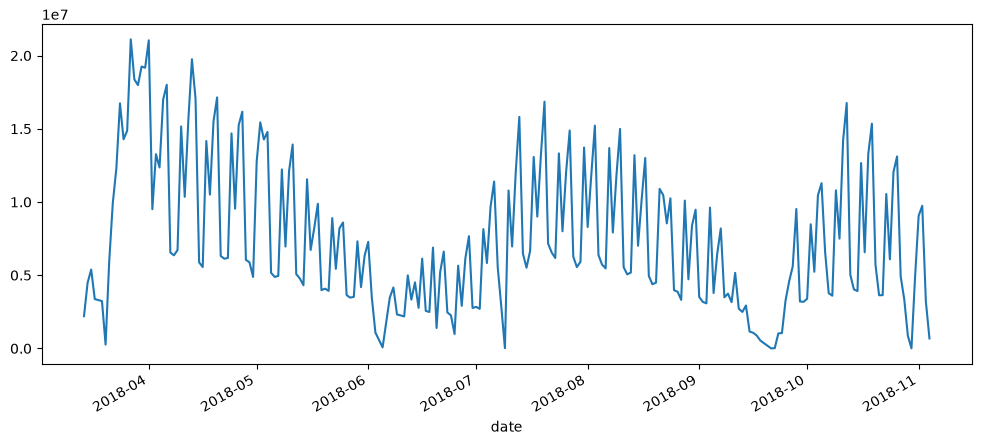

In [45]:
# Evolución en el tiempo
df.groupby("date")["total_sales"].sum().plot(figsize=(12,5))

<Axes: xlabel='month_name'>

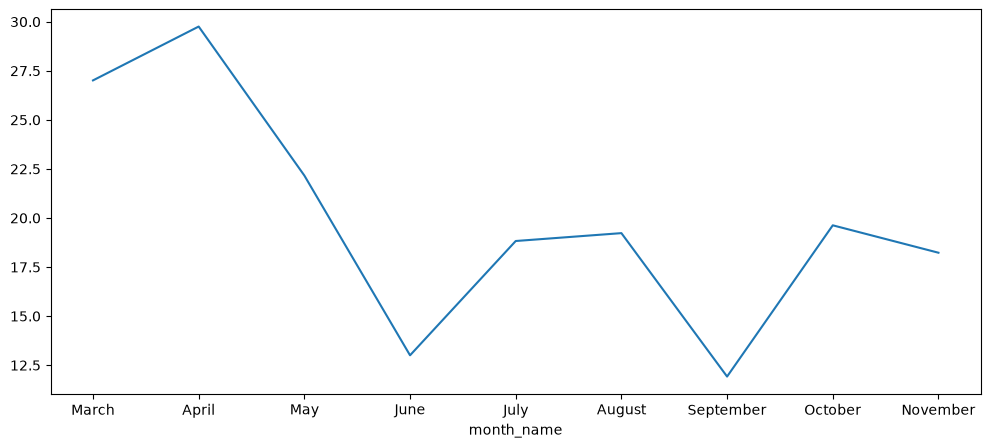

In [58]:
# Variación de la ocupación de las salas
df.groupby("month_name")["occu_perc"].mean().reindex(month_order).plot(figsize=(12, 5))

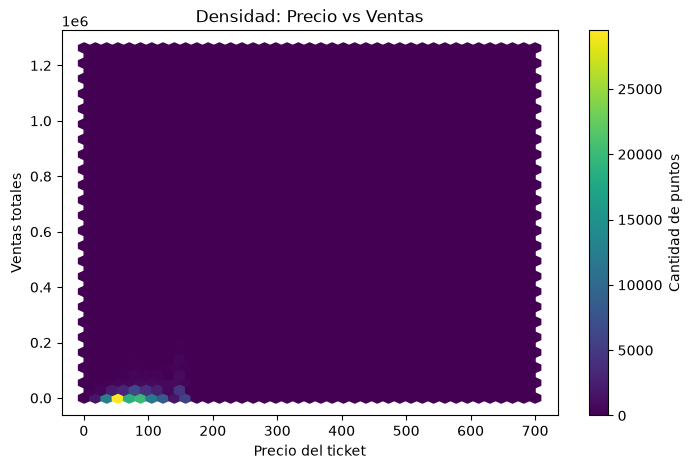

In [64]:
# Relacion precio ticket y ventas
plt.figure(figsize=(8,5))
plt.hexbin(df["ticket_price"], df["total_sales"], gridsize=40, cmap="viridis")
plt.colorbar(label="Cantidad de puntos")
plt.xlabel("Precio del ticket")
plt.ylabel("Ventas totales")
plt.title("Densidad: Precio vs Ventas")
plt.show()

In [ ]:
# ↑ Concentración muy fuerte de datos en la esquina inferior izquierda ↑
# Precios aproximadamente entre 30 y 120

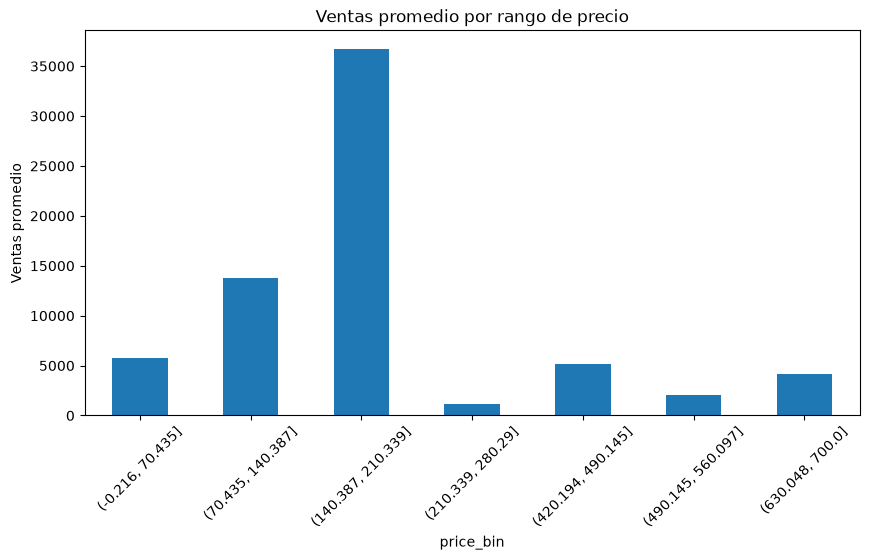

In [65]:
df["price_bin"] = pd.cut(df["ticket_price"], bins=10)

avg = df.groupby("price_bin")["total_sales"].mean()

avg.plot(kind="bar", figsize=(10,5))
plt.ylabel("Ventas promedio")
plt.title("Ventas promedio por rango de precio")
plt.xticks(rotation=45)
plt.show()